# Figure 1, step by step

The human-annotation analysis behind manuscript Figure 1, computed top to bottom
in one readable pass. Every step is numbered, runs in order, prints what it did,
and draws the panel it feeds.

## Embeddings: SapBERT throughout

The project previously used two embedding models. `framework/normalization/`
used SapBERT, while tier 5 of `framework/benchmark/semantic_matcher.py` used
SciBERT. As of 2026-09-04 the whole pipeline uses SapBERT.

The reason is measured, not stylistic, and step 16 reproduces it. On 88,226
value pairs drawn from genuinely unrelated annotation fields, an Organism value
against a CleavageAgent value and so on, where no true match is possible:

| Model | median cosine | max | share at or above 0.70 |
| --- | ---: | ---: | ---: |
| SciBERT | 0.631 | 0.906 | **18.2%** |
| SapBERT | see step 16 | | |

SciBERT scores topical relatedness rather than synonymy on short domain terms,
so roughly one unrelated pair in five passed the threshold. SapBERT is trained
on UMLS synonymy, which is the question actually being asked.

Encoding here is `[CLS]`, L2-normalised, max 128 tokens, matching
`framework/normalization/index.py._embed_texts` exactly.

**Reads:** `EuBIC-annotation/` and nothing else
**Writes:** `final_analyses/HumanAnnotation/results/`

## Settings

`EMBEDDING_MODEL` is the only switch. Leave it on `"sapbert"`. Setting it to
`"scibert"` reproduces the superseded configuration, which is useful only for
re-checking the comparison in step 16.

In [1]:
import itertools
import json
import statistics
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import kruskal, spearmanr, wilcoxon

# --- where things live -------------------------------------------------------
NOTEBOOK_DIR = Path.cwd()
REPO = next(p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (p / "EuBIC-annotation").exists())
ANNOTATIONS = REPO / "EuBIC-annotation"
RESULTS = REPO / "final_analyses" / "HumanAnnotation" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO / "framework"))

# --- the one switch ----------------------------------------------------------
EMBEDDING_MODEL = "sapbert"     # "sapbert" (the pipeline) or "scibert" (superseded)

# Two values count as meaning the same thing at or above this cosine.
# 0.70 is what run_sdrf_benchmark.py passes to the matcher.
SEMANTIC_THRESHOLD = 0.70

# --- label filters -----------------------------------------------------------
# A label must be mentioned in at least this many of the 27 papers (judged by
# the harmonised consensus). Below it, kappa comes from one or two instances.
MIN_MENTIONS = 3
# And tagged by at least this many different human annotators somewhere in the
# corpus. A label only one person ever used was never a consensus.
MIN_UNIQUE_ANNOTATORS = 2

# --- identities --------------------------------------------------------------
MODELS = {"Qwen": "qwen3_8_27b", "Gemma": "gemma4_31b", "GLM": "glm4_7"}

# GPT is the original EuBIC-era model annotation. Its version was never
# recorded and three pinned models supersede it. The files stay on disk.
EXCLUDE = {"GPT"}

# SingleHuman annotated all 27 papers. Leaving them out of "human vs human"
# would silently drop a rater.
HUMAN_PAIR_TYPES = {
    "MultiHuman annotator vs. MultiHuman annotator",
    "SingleHuman vs. MultiHuman annotator",
}

stats = {"embedding_model": EMBEDDING_MODEL, "semantic_threshold": SEMANTIC_THRESHOLD}
print(f"repo:  {REPO}")
print(f"model: {EMBEDDING_MODEL}   threshold: {SEMANTIC_THRESHOLD}")

repo:  /home/tine/git/Publication/textmining
model: sapbert   threshold: 0.7


Every label observed in the corpus, assigned to one of the three metadata
categories. Written out in full so the notebook depends on no other file.

In [2]:
LABEL_CATEGORY = {
    # --- biological ----------------------------------------------------------
    "Organism": "biological", "OrganismPart": "biological", "Disease": "biological",
    "CellLine": "biological", "CellType": "biological", "Strain": "biological",
    "Sex": "biological", "Age": "biological", "DevelopmentalStage": "biological",
    "MaterialType": "biological", "CellPart": "biological", "Specimen": "biological",
    "TumorStage": "biological", "TumorSite": "biological", "TumorGrade": "biological",
    "TumorCellularity": "biological", "AnatomicSiteTumor": "biological",
    "OriginSiteDisease": "biological", "GeneticModification": "biological",
    "GrowthRate": "biological", "Bait": "biological", "SourceName": "biological",
    "DiseaseTreatment": "biological", "SpikedCompound": "biological",
    "Compound": "biological", "ConcentrationOfCompound": "biological",
    "PooledSample": "biological", "Staining": "biological", "Depletion": "biological",
    "Treatment": "biological",
    # --- technical -----------------------------------------------------------
    "Modification": "technical", "Label": "technical", "AcquisitionMethod": "technical",
    "CleavageAgent": "technical", "Separation": "technical", "Instrument": "technical",
    "FragmentationMethod": "technical", "ReductionReagent": "technical",
    "PrecursorMassTolerance": "technical", "AlkylationReagent": "technical",
    "GradientTime": "technical", "FlowRateChromatogram": "technical",
    "Temperature": "technical", "Chromatography": "technical",
    "FractionationMethod": "technical", "NumberOfMissedCleavages": "technical",
    "MS2MassAnalyzer": "technical", "IonizationType": "technical",
    "FragmentMassTolerance": "technical", "CollisionEnergy": "technical",
    "EnrichmentMethod": "technical", "SupplementaryFile": "technical",
    "AssayName": "technical", "SyntheticPeptide": "technical",
    # --- experimental design -------------------------------------------------
    "FactorValue": "experimental_design", "SampleTreatment": "experimental_design",
    "NumberOfSamples": "experimental_design", "NumberOfBiologicalReplicates": "experimental_design",
    "NumberOfTechnicalReplicates": "experimental_design", "BiologicalReplicate": "experimental_design",
    "TechnicalReplicate": "experimental_design", "Experiment": "experimental_design",
    "TechnologyType": "experimental_design", "Time": "experimental_design",
    "SamplingTime": "experimental_design", "NumberOfFractions": "experimental_design",
    "FractionIdentifier": "experimental_design", "FractionationFraction": "experimental_design",
}
CATEGORY_ORDER = ["biological", "technical", "experimental_design"]
print(f"{len(LABEL_CATEGORY)} labels defined")

68 labels defined


Two things are used often enough to deserve a name. Everything else is inline.

In [3]:
def cohen_kappa(labels_a, labels_b):
    """Cohen's kappa over two aligned lists of categorical judgments.

    Any number of categories. Presence/absence is just the case where the two
    categories are 0 and 1, so this one function covers both the presence
    analysis and the value analysis.
    """
    if not labels_a or len(labels_a) != len(labels_b):
        return float("nan")
    n = len(labels_a)

    observed = sum(1 for x, y in zip(labels_a, labels_b) if x == y) / n

    count_a, count_b = Counter(labels_a), Counter(labels_b)
    expected = sum((count_a.get(c, 0) / n) * (count_b.get(c, 0) / n)
                   for c in set(count_a) | set(count_b))

    if abs(1 - expected) < 1e-12:
        return float("nan")
    return (observed - expected) / (1 - expected)


def pair_type(a, b):
    """Describe an annotator pair, e.g. 'model vs. model'.

    The model roles matter. Without them Qwen, Gemma and GLM fall through to
    'multi' and get counted as human annotators, contaminating every
    human-human number with model agreement.
    """
    def role(name):
        if name in MODELS:
            return "model"
        if name == "HarmonizedHuman":
            return "harmonized"
        if name == "SingleHuman":
            return "single"
        return "multi"

    roles = {role(a), role(b)}
    if roles == {"model"}:
        return "model vs. model"
    if "model" in roles:
        return "model vs. any human annotator"
    if "harmonized" in roles:
        return "HarmonizedHuman vs. any human annotator"
    if "single" in roles:
        return "SingleHuman vs. MultiHuman annotator"
    return "MultiHuman annotator vs. MultiHuman annotator"

## Drawing

Panels come from `build_figure1.py`, imported rather than copied, so the
notebook cannot draw something the manuscript figure does not. Each panel reads
the CSV written by the step above it, which is why they appear as we go rather
than all at the end.

In [4]:
import importlib
import io

import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, str(REPO / "final_analyses" / "HumanAnnotation" / "scripts"))
import build_figure1


def draw(panel, figsize, with_colorbars=False):
    """Re-read the tables, render one panel, show it.

    build_figure1 selects the Agg backend on import, so a returned Figure would
    display nothing. Rendering to PNG bytes here works whatever the backend is,
    which also means the notebook and the saved figure come off the same path.
    """
    importlib.reload(build_figure1)            # pick up the CSVs just written
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    if with_colorbars:                          # panel a needs two of them
        getattr(build_figure1, panel)(
            ax,
            cbar_lower=ax.inset_axes([1.03, 0.06, 0.022, 0.20]),
            cbar_upper=ax.inset_axes([1.03, 0.32, 0.022, 0.20]))
    else:
        getattr(build_figure1, panel)(ax)

    fig.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


print("panels available:", [n for n in dir(build_figure1) if n.startswith("panel_")])

panels available: ['panel_a', 'panel_b', 'panel_c', 'panel_d', 'panel_e']


## Step 1. Read every annotation file off disk

Three file formats are in play and none of them fails loudly when read with the
wrong parser, so each gets its own reader.

- **BRAT, tab-delimited** `T1<TAB>Organism 100 106<TAB>human` — the human sets
- **Flat** `Label : value` — HarmonizedHuman and GPT, not real BRAT spans
- **Pipe-delimited** `T1|||Organism 100 106|||human` — the three model sets,
  which are also keyed by PXD accession while every human set is keyed by PMID

In [5]:
annotations = defaultdict(dict)   # {annotator: {document: {label: [values]}}}

# --- format A: real BRAT, tab-delimited T-lines ------------------------------
for path in sorted((ANNOTATIONS / "SingleHuman").glob("*.ann")):
    entries = defaultdict(list)
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        if line.startswith("T"):
            parts = line.split("\t")
            if len(parts) >= 3:
                entries[parts[1].split()[0]].append(parts[2].strip())
    annotations["SingleHuman"][path.stem] = dict(entries)

for path in sorted(ANNOTATIONS.glob("MultiHuman/*/*/*.ann")):
    annotator = path.parts[-3]
    # MultiHuman/Ian/ is byte-identical to SingleHuman. Keeping both would
    # count one person twice.
    if annotator.lower() == "ian":
        continue
    entries = defaultdict(list)
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        if line.startswith("T"):
            parts = line.split("\t")
            if len(parts) >= 3:
                entries[parts[1].split()[0]].append(parts[2].strip())
    annotations[annotator][path.stem] = dict(entries)

# --- format B: flat "Label : value" ------------------------------------------
for source, pattern, suffix in [("GPT", "GPT/*.ann", ""),
                                ("HarmonizedHuman", "HarmonizedHuman/*.ann", "_harmonized")]:
    for path in sorted(ANNOTATIONS.glob(pattern)):
        entries = defaultdict(list)
        for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
            if ":" in line:
                label, value = line.split(":", 1)
                if label.strip() and value.strip():
                    entries[label.strip()].append(value.strip())
        annotations[source][path.stem.removesuffix(suffix) if suffix else path.stem] = dict(entries)

# --- format C: the model sets, "|||" delimited, keyed by PXD -----------------
pxd_to_pmid = dict(
    pd.read_csv(ANNOTATIONS / "pxd_pmid_mapping.csv", dtype=str)[["pxd", "pmid"]]
      .itertuples(index=False, name=None))

for model_name, dirname in MODELS.items():
    model_dir = ANNOTATIONS / "s0_model_iaa_27" / "final_annotations" / dirname / "ann_files"
    if not model_dir.exists():
        print(f"  WARNING: {model_dir} missing, {model_name} skipped")
        continue
    for path in sorted(model_dir.glob("*.ann")):
        pmid = pxd_to_pmid.get(path.stem)
        if pmid is None:
            continue                      # unmapped accession, skip rather than guess
        entries = defaultdict(list)
        for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
            if line.startswith("T"):
                parts = line.split("|||")
                if len(parts) >= 3 and parts[2].strip():
                    entries[parts[1].split()[0]].append(parts[2].strip())
        annotations[model_name][pmid] = dict(entries)

annotations = {k: v for k, v in annotations.items() if k not in EXCLUDE}
print(f"{len(annotations)} identities: {', '.join(sorted(annotations))}")

13 identities: GLM, Gemma, HarmonizedHuman, Julian, Karolina, Magnus, Maike, Marta, Qwen, Samuel, SingleHuman, Tim, Tine


## Step 2. Anonymise the human annotators

The eight EuBIC annotators become Annotator1..8 in alphabetical order of their
real names. The mapping is written out so it stays recoverable.

In [6]:
named_roles = {"SingleHuman", "HarmonizedHuman"} | set(MODELS)
real_names = sorted(name for name in annotations if name not in named_roles)
anon_of = {real: f"Annotator{i + 1}" for i, real in enumerate(real_names)}

annotations = {anon_of.get(name, name): docs for name, docs in annotations.items()}

pd.DataFrame([{"anonymized_id": anon, "real_name": real} for real, anon in anon_of.items()]
             ).to_csv(ANNOTATIONS / "annotator_name_mapping.csv", index=False)

# Fixed display order: special human identities, anonymised annotators, models.
multihuman = sorted(anon_of.values(), key=lambda n: int(n.removeprefix("Annotator")))
identities = ([n for n in ("SingleHuman", "HarmonizedHuman") if n in annotations]
              + multihuman
              + [m for m in MODELS if m in annotations])

print(f"{len(multihuman)} anonymised annotators, {len(identities)} identities")
print(identities)

8 anonymised annotators, 13 identities
['SingleHuman', 'HarmonizedHuman', 'Annotator1', 'Annotator2', 'Annotator3', 'Annotator4', 'Annotator5', 'Annotator6', 'Annotator7', 'Annotator8', 'Qwen', 'Gemma', 'GLM']


## Step 3. Decide which labels enter the analysis

Two filters. A label failing either is dropped everywhere downstream.

In [7]:
consensus_docs = annotations["HarmonizedHuman"]
n_documents = len(consensus_docs)
all_labels = sorted(LABEL_CATEGORY)

mentions = {label: sum(1 for e in consensus_docs.values() if e.get(label))
            for label in all_labels}
annotators_using = {label: sum(1 for a in multihuman
                               if any(e.get(label) for e in annotations[a].values()))
                    for label in all_labels}

labels = [l for l in all_labels
          if mentions[l] >= MIN_MENTIONS and annotators_using[l] >= MIN_UNIQUE_ANNOTATORS]

print(f"kept {len(labels)}/{len(all_labels)} labels")
print(f"dropped, fewer than {MIN_MENTIONS} mentions: "
      f"{[l for l in all_labels if mentions[l] < MIN_MENTIONS]}")
print(f"dropped, single annotator only: "
      f"{[l for l in all_labels if mentions[l] >= MIN_MENTIONS and annotators_using[l] < MIN_UNIQUE_ANNOTATORS]}")

stats |= {"n_labels": len(labels), "n_docs": n_documents, "n_identities": len(identities)}

kept 42/68 labels
dropped, fewer than 3 mentions: ['AnatomicSiteTumor', 'AssayName', 'Bait', 'BiologicalReplicate', 'Depletion', 'DiseaseTreatment', 'GeneticModification', 'GrowthRate', 'MaterialType', 'OriginSiteDisease', 'SourceName', 'Specimen', 'SpikedCompound', 'SyntheticPeptide', 'TechnicalReplicate', 'TechnologyType', 'TumorCellularity', 'TumorGrade', 'TumorStage']
dropped, single annotator only: ['CellPart', 'ConcentrationOfCompound', 'DevelopmentalStage', 'Experiment', 'FlowRateChromatogram', 'Temperature', 'TumorSite']


## Step 4. Build the presence matrix

For every identity, every document they annotated and every kept label: did they
mark this label at all? The coarsest question in the analysis, and what panels b
and c are built on.

In [8]:
presence = {
    identity: {doc_id: {label: int(bool(entries.get(label))) for label in labels}
               for doc_id, entries in docs.items()}
    for identity, docs in annotations.items()
}
print(f"{sum(len(d) for d in presence.values()) * len(labels):,} "
      f"identity-document-label slots")

8,694 identity-document-label slots


## Step 5. Presence agreement per label per pair &rarr; panel c, y axis

One kappa for every (pair of identities, label). Only documents both identities
annotated are compared.

In [9]:
rows = []
for a, b in itertools.combinations(identities, 2):
    shared = sorted(set(presence[a]) & set(presence[b]))
    for label in labels:
        rows.append({
            "label": label, "category": LABEL_CATEGORY[label],
            "annotator_a": a, "annotator_b": b, "pair_category": pair_type(a, b),
            "n_shared_docs": len(shared),
            "kappa": cohen_kappa([presence[a][d][label] for d in shared],
                                 [presence[b][d][label] for d in shared]),
        })
label_pairs = pd.DataFrame(rows)
label_pairs.to_csv(RESULTS / "label_agreement_presence.csv", index=False)
print(f"{len(label_pairs):,} rows -> label_agreement_presence.csv")
label_pairs.head()

3,276 rows -> label_agreement_presence.csv


,label,category,annotator_a,annotator_b,pair_category,n_shared_docs,kappa
0,AcquisitionMethod,technical,SingleHuman,HarmonizedHuman,HarmonizedHuman vs. any human annotator,27,0.847458
1,Age,biological,SingleHuman,HarmonizedHuman,HarmonizedHuman vs. any human annotator,27,0.630137
2,AlkylationReagent,technical,SingleHuman,HarmonizedHuman,HarmonizedHuman vs. any human annotator,27,0.653846
3,CellLine,biological,SingleHuman,HarmonizedHuman,HarmonizedHuman vs. any human annotator,27,0.823529
4,CellType,biological,SingleHuman,HarmonizedHuman,HarmonizedHuman vs. any human annotator,27,0.562162


## Step 6. How often is each label mentioned? &rarr; panel c, x axis

In [10]:
mention_rates = pd.DataFrame([{
    "label": label, "category": LABEL_CATEGORY[label], "n_docs": n_documents,
    "mention_rate": sum(d[label] for d in presence["HarmonizedHuman"].values()) / n_documents,
} for label in labels])
mention_rates.to_csv(RESULTS / "label_mention_rate.csv", index=False)
mention_rates.sort_values("mention_rate", ascending=False).head(10)

,label,category,n_docs,mention_rate
18,Instrument,technical,27,1.000000
6,CleavageAgent,technical,27,0.962963
35,Separation,technical,27,0.962963
28,Organism,biological,27,0.925926
11,FactorValue,experimental_design,27,0.851852
31,PrecursorMassTolerance,technical,27,0.777778
16,FragmentationMethod,technical,27,0.777778
22,Modification,technical,27,0.777778
32,ReductionReagent,technical,27,0.777778
2,AlkylationReagent,technical,27,0.777778


### Panel c

Per-label presence agreement against how often the field is stated. If the hard
fields were simply the uncommon ones, this would slope upwards.

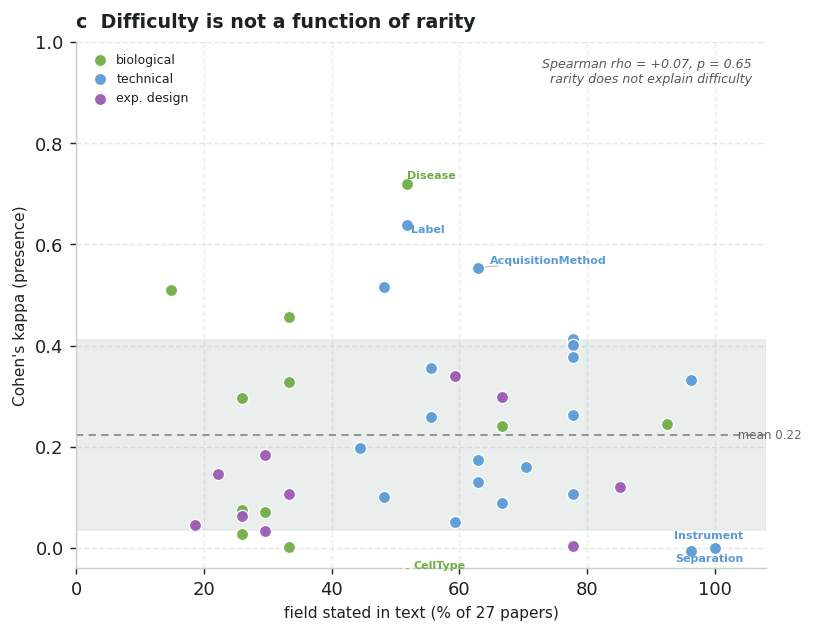

In [11]:
draw("panel_c", (6.4, 5.0))

## Step 7. Is model agreement just shared silence? &rarr; panel b

Most slots are empty for most raters, so two sparse annotators agree on a great
many absences. Kappa is supposed to subtract that, but kappa misbehaves when the
marginals are skewed, so treat "kappa handles it" as a claim to test rather than
a defence to offer.

The full 2&times;2 table per pair gives three checks that do not rely on kappa:

| Quantity | What it tells you |
| --- | --- |
| `chance_agreement` | if shared sparsity inflated model kappa, this would be **higher** for model pairs, not lower |
| `both_absent_share` | the direct measure of the worry |
| `positive_agreement` | `2n11 / (2n11 + n10 + n01)`. The both-absent cell does not appear, so shared silence cannot inflate it at all |

HarmonizedHuman is excluded here: it is derived from the annotators, so pairing
it with them measures reconciliation, not independent agreement.

In [12]:
raters = [r for r in identities if r != "HarmonizedHuman"]

rows = []
for a, b in itertools.combinations(raters, 2):
    both = only_a = only_b = neither = 0
    for doc in sorted(set(presence[a]) & set(presence[b])):
        for label in labels:
            x, y = bool(presence[a][doc][label]), bool(presence[b][doc][label])
            if x and y:      both += 1
            elif x:          only_a += 1
            elif y:          only_b += 1
            else:            neither += 1

    n = both + only_a + only_b + neither
    if n == 0:
        continue

    observed = (both + neither) / n
    prevalence_a, prevalence_b = (both + only_a) / n, (both + only_b) / n
    chance = prevalence_a * prevalence_b + (1 - prevalence_a) * (1 - prevalence_b)
    positive_denominator = 2 * both + only_a + only_b

    group = ("model-model" if a in MODELS and b in MODELS else
             "model-human" if a in MODELS or b in MODELS else "human-human")

    rows.append({
        "group": group, "annotator_a": a, "annotator_b": b,
        "kappa": (observed - chance) / (1 - chance) if chance < 1 else float("nan"),
        "raw_agreement": observed, "chance_agreement": chance,
        "positive_agreement": (2 * both / positive_denominator) if positive_denominator else float("nan"),
        "both_absent_share": neither / n,
        "prevalence_a": prevalence_a, "prevalence_b": prevalence_b, "n_slots": n,
    })

decomposition = pd.DataFrame(rows)
decomposition.to_csv(RESULTS / "agreement_decomposition.csv", index=False)

# How much does each rater mark at all? This is where the mechanism shows up.
prevalence = {}
for rater in raters:
    docs = presence[rater]
    total = len(docs) * len(labels)
    prevalence[rater] = (sum(1 for d in docs for l in labels if docs[d][l]) / total
                         if total else float("nan"))

human_prev = [v for k, v in prevalence.items() if k not in MODELS]
model_prev = [v for k, v in prevalence.items() if k in MODELS]
stats["prevalence"] = {
    "human_min": min(human_prev), "human_max": max(human_prev),
    "human_fold": max(human_prev) / min(human_prev),
    "model_min": min(model_prev), "model_max": max(model_prev),
    "model_fold": max(model_prev) / min(model_prev),
}
stats["decomposition"] = {
    g: {c: float(s[c].mean()) for c in ("kappa", "raw_agreement", "chance_agreement",
                                        "positive_agreement", "both_absent_share")}
       | {"n_pairs": int(len(s))}
    for g, s in decomposition.groupby("group")}
stats["presence_kappa"] = {
    g.replace("-", "_"): {"mean": float(s["kappa"].mean()), "min": float(s["kappa"].min()),
                          "max": float(s["kappa"].max()), "n": int(len(s))}
    for g, s in decomposition.groupby("group")}

print("group           n   kappa     raw  chance  pos.agr  both-absent")
for g in ("human-human", "model-human", "model-model"):
    s = stats["decomposition"].get(g)
    if s:
        print(f"{g:14s} {s['n_pairs']:3d} {s['kappa']:7.3f} {s['raw_agreement']:7.3f} "
              f"{s['chance_agreement']:7.3f} {s['positive_agreement']:8.3f} "
              f"{s['both_absent_share']:12.3f}")
p = stats["prevalence"]
print(f"\nprevalence: humans {p['human_min']:.3f}-{p['human_max']:.3f} ({p['human_fold']:.1f}-fold), "
      f"models {p['model_min']:.3f}-{p['model_max']:.3f} ({p['model_fold']:.2f}-fold)")

group           n   kappa     raw  chance  pos.agr  both-absent
human-human     35   0.427   0.747   0.556    0.605        0.543
model-human     27   0.400   0.716   0.526    0.612        0.482
model-model      3   0.690   0.849   0.512    0.820        0.504

prevalence: humans 0.167-0.439 (2.6-fold), models 0.409-0.434 (1.06-fold)


### Panel b

The decomposition. Watch `chance_agreement`: if model agreement were an artefact
of both models declining to annotate, the model bar would be the tallest here,
not the shortest.

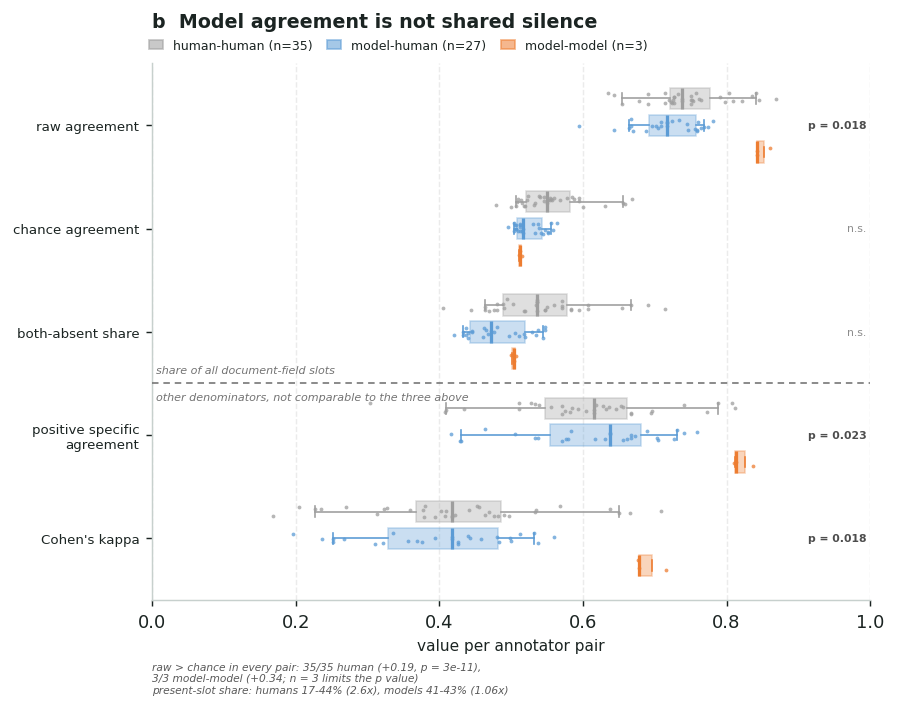

In [13]:
draw("panel_b", (7.0, 5.6))

## Step 8. Significance, three different questions

1. **Is agreement above chance at all?** Paired within each pair, so a
   signed-rank test on `raw - chance`. The pairs share raters and are not
   independent, which makes the p-value anticonservative. The robust statement
   is the count: the difference is positive in every pair.
2. **Do the three groups differ at all?** Kruskal-Wallis, same caveat.
3. **Model-model against human-human specifically.** A rank test over pairs
   would assume the pairs are independent. They are not: each rater appears in
   up to eleven of them, so one unusual annotator moves many pairs at once.
   Permuting which *raters* are models respects that. With 12 raters and 3
   models there are only C(12,3) = 220 assignments, so this enumerates all of
   them exactly. The smallest attainable p is 1/220 = 0.0045.

In [14]:
stats["tests"] = {}

# --- 8a. above chance? -------------------------------------------------------
raw_vs_chance = {}
for group, sub in decomposition.groupby("group"):
    excess = (sub["raw_agreement"] - sub["chance_agreement"]).dropna()
    entry = {"n": int(len(excess)), "n_positive": int((excess > 0).sum()),
             "mean_excess": float(excess.mean())}
    if len(excess) >= 6:
        entry["wilcoxon_p"] = float(wilcoxon(excess, alternative="greater")[1])
    else:
        # n=3 cannot reach 0.05 in a signed-rank test. Report the exact
        # sign-test floor instead of a number that only looks like a p-value.
        entry["sign_test_p"] = float(0.5 ** len(excess))
    raw_vs_chance[group] = entry
stats["tests"]["raw_vs_chance"] = raw_vs_chance

# --- 8b. do the groups differ? -----------------------------------------------
for metric in ("kappa", "positive_agreement", "chance_agreement", "both_absent_share"):
    groups = [s[metric].dropna().values for _, s in decomposition.groupby("group")]
    groups = [g for g in groups if len(g)]
    if len(groups) >= 2 and sum(len(g) for g in groups) > len(groups):
        H, pv = kruskal(*groups)
        stats["tests"].setdefault("kruskal", {})[metric] = {
            "H": float(H), "p": float(pv), "n_per_group": [int(len(g)) for g in groups]}

# --- 8c. exact rater permutation test ----------------------------------------
model_raters = [r for r in raters if r in MODELS]
stats["tests"]["permutation"] = {}

for metric in ("kappa", "positive_agreement", "chance_agreement",
               "both_absent_share", "raw_agreement"):
    values = {(r["annotator_a"], r["annotator_b"]): r[metric]
              for _, r in decomposition.iterrows()}

    def difference_if_models_were(model_set):
        """Mean over model-model pairs minus mean over human-human pairs."""
        mm = [v for (a, b), v in values.items() if a in model_set and b in model_set]
        hh = [v for (a, b), v in values.items() if a not in model_set and b not in model_set]
        return statistics.fmean(mm) - statistics.fmean(hh) if mm and hh else None

    observed = difference_if_models_were(set(model_raters))
    if observed is None:
        continue
    all_differences = [d for d in (difference_if_models_were(set(c))
                                   for c in itertools.combinations(raters, len(model_raters)))
                       if d is not None]
    stats["tests"]["permutation"][metric] = {
        "metric": metric, "observed_diff": observed,
        "n_permutations": len(all_differences),
        "p_two_sided": sum(1 for d in all_differences
                           if abs(d) >= abs(observed) - 1e-12) / len(all_differences),
    }

print("model-model vs human-human, exact rater permutation test:")
for metric, res in stats["tests"]["permutation"].items():
    print(f"  {metric:20s} diff {res['observed_diff']:+.3f}  p = {res['p_two_sided']:.4f}  "
          f"({res['n_permutations']} permutations)")
print("\nraw agreement above chance:")
for group, e in raw_vs_chance.items():
    extra = (f"Wilcoxon p={e['wilcoxon_p']:.2g}" if "wilcoxon_p" in e
             else f"sign-test floor p={e['sign_test_p']:.2g}")
    print(f"  {group:14s} +{e['mean_excess']:.3f} in {e['n_positive']}/{e['n']} pairs, {extra}")

model-model vs human-human, exact rater permutation test:
  kappa                diff +0.263  p = 0.0182  (220 permutations)
  positive_agreement   diff +0.216  p = 0.0227  (220 permutations)
  chance_agreement     diff -0.043  p = 0.2636  (220 permutations)
  both_absent_share    diff -0.039  p = 0.5455  (220 permutations)
  raw_agreement        diff +0.102  p = 0.0182  (220 permutations)

raw agreement above chance:
  human-human    +0.191 in 35/35 pairs, Wilcoxon p=2.9e-11
  model-human    +0.190 in 27/27 pairs, Wilcoxon p=2.8e-06
  model-model    +0.337 in 3/3 pairs, sign-test floor p=0.12


## Step 9. Load the embedding model

Everything from here asks whether two different strings mean the same thing.

For SciBERT this uses the framework's own `SemanticMatcher`, the same object the
pipeline's tier 5 uses, so the notebook measures what the pipeline does rather
than an approximation of it. Encoding is SentenceTransformer over
`allenai/scibert_scivocab_uncased`, lower-cased and L2-normalised.

The whole vocabulary is embedded once, in sorted order. That is not an
optimisation, it is a correctness fix. A transformer pads each batch to its
longest member, so the same string embedded beside different neighbours comes
back differing in the last bits. Clustering in step 11 takes connected
components, which is transitive, so one edge flipping at the threshold merges
two whole clusters and moves kappa by more than a rounding error. Embedding in a
fixed order makes the result independent of the order later steps ask for values.

In [15]:
def tidy(value):
    return " ".join(value.strip().lower().split())


import torch
from transformers import AutoModel, AutoTokenizer

model_name = ("cambridgeltl/SapBERT-from-PubMedBERT-fulltext" if EMBEDDING_MODEL == "sapbert"
              else "allenai/scibert_scivocab_uncased")

_tok = AutoTokenizer.from_pretrained(model_name)
_mod = AutoModel.from_pretrained(model_name)
_mod.eval()


def _encode(texts):
    """[CLS] token, L2-normalised, max 128 tokens, in batches of 64.

    Identical to framework/normalization/index.py._embed_texts and to tier 5 of
    framework/benchmark/semantic_matcher.py, so a value sits at the same point
    in the space here as it does in the pipeline.
    """
    out = []
    for i in range(0, len(texts), 64):
        encoded = _tok([t.lower().strip() for t in texts[i:i + 64]],
                       padding=True, truncation=True, max_length=128,
                       return_tensors="pt")
        with torch.no_grad():
            hidden = _mod(**encoded).last_hidden_state
        out.append(torch.nn.functional.normalize(hidden[:, 0, :], dim=1).numpy())
    return np.vstack(out)

# --- embed the whole vocabulary once, deterministically ----------------------
vocabulary = sorted({v for docs in annotations.values() for entries in docs.values()
                     for label in labels for value in entries.get(label, [])
                     for v in (value, tidy(value))})
_vectors = _encode(vocabulary)
embedding_cache = dict(zip(vocabulary, _vectors))


def embed(texts):
    """Unit-normalised vector per string, from the pre-built cache."""
    missing = [t for t in dict.fromkeys(texts) if t not in embedding_cache]
    if missing:
        embedding_cache.update(zip(missing, _encode(missing)))
    return np.stack([embedding_cache[t] for t in texts])


stats["embedding_model_name"] = model_name
print(f"{model_name}: embedded {len(vocabulary):,} distinct strings")

/home/tine/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7867.16it/s]

cambridgeltl/SapBERT-from-PubMedBERT-fulltext: embedded 4,758 distinct strings


## Step 10. Exact against conceptual match, per instance &rarr; panel d

Only cases where **both** identities tagged the label. Cases where one tagged it
and the other did not are a presence disagreement, already counted in step 5.

An instance is an exact match if any value string is shared. If not, it is a
semantic match when the closest pair of values reaches the threshold.

In [16]:
rows = []
for a, b in itertools.combinations(identities, 2):
    for doc in sorted(set(presence[a]) & set(presence[b])):
        for label in labels:
            values_a = annotations[a][doc].get(label, [])
            values_b = annotations[b][doc].get(label, [])
            if not values_a or not values_b:
                continue

            exact = bool({v.strip().lower() for v in values_a}
                         & {v.strip().lower() for v in values_b})
            similarity = (None if exact
                          else float((embed(values_a) @ embed(values_b).T).max()))

            rows.append({
                "label": label, "category": LABEL_CATEGORY[label],
                "annotator_a": a, "annotator_b": b, "doc": doc,
                "exact_match": exact,
                "semantic_match": similarity is not None and similarity >= SEMANTIC_THRESHOLD,
                "similarity": similarity,
            })

value_instances = pd.DataFrame(rows)

per_label = value_instances.groupby("label").agg(
    n=("exact_match", "size"), exact=("exact_match", "sum"),
    semantic=("semantic_match", "sum")).reset_index()
per_label["category"] = per_label["label"].map(LABEL_CATEGORY)
per_label["exact_pct"] = 100 * per_label["exact"] / per_label["n"]
per_label["semantic_pct"] = 100 * per_label["semantic"] / per_label["n"]
per_label["no_match_pct"] = 100 - per_label["exact_pct"] - per_label["semantic_pct"]
per_label.to_csv(RESULTS / "value_match_by_label.csv", index=False)

stats["value_match"] = {
    "n_instances": int(len(value_instances)),
    "exact_pct": 100 * float(value_instances["exact_match"].mean()),
    "semantic_pct": 100 * float(value_instances["semantic_match"].mean()),
}
stats["value_match"]["no_match_pct"] = (100 - stats["value_match"]["exact_pct"]
                                        - stats["value_match"]["semantic_pct"])

print(f"{len(value_instances):,} both-tagged instances: "
      f"exact {stats['value_match']['exact_pct']:.1f}%  "
      f"{EMBEDDING_MODEL}-only {stats['value_match']['semantic_pct']:.1f}%  "
      f"none {stats['value_match']['no_match_pct']:.1f}%")

8,286 both-tagged instances: exact 73.4%  sapbert-only 15.0%  none 11.6%


### Panel d

Exact match, recovered by the embedding, and residual mismatch, per label. The
middle band is the vocabulary problem: same meaning, different words.

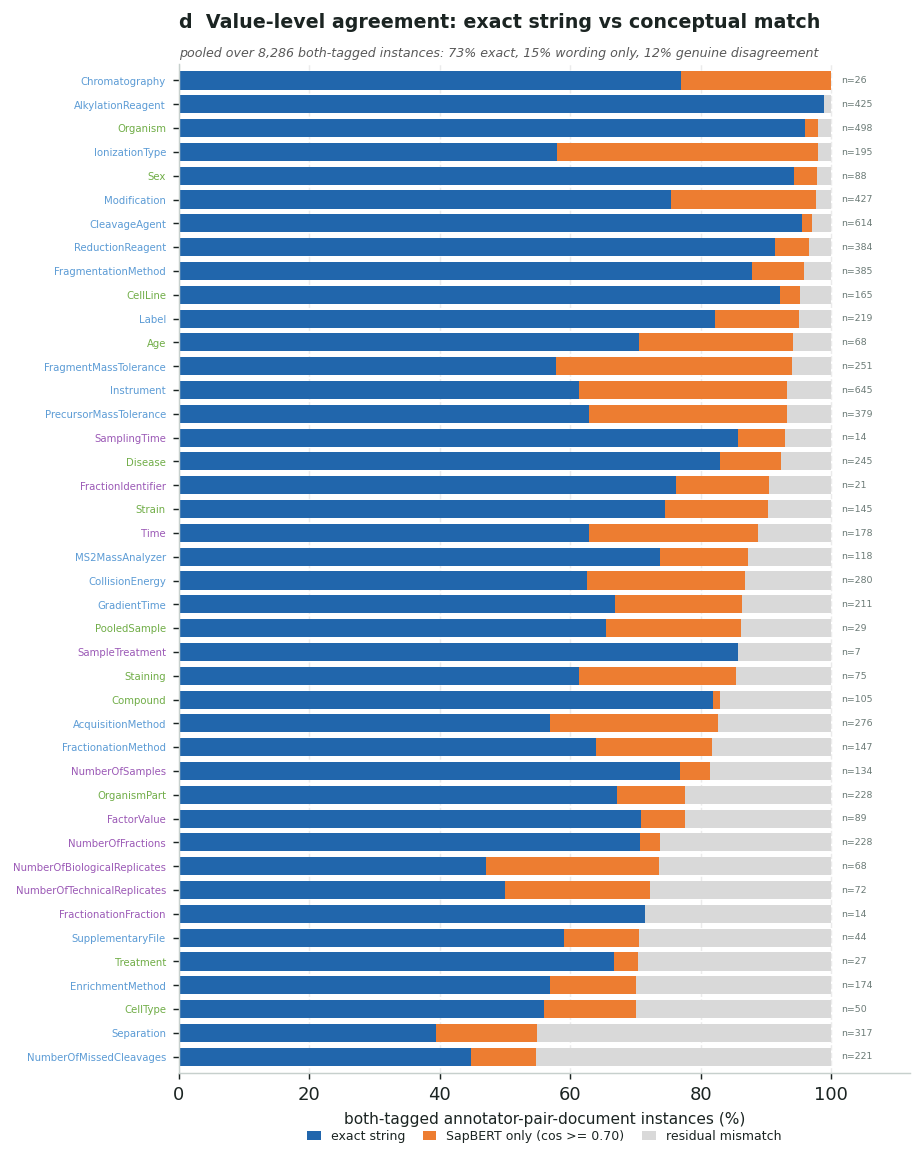

In [17]:
draw("panel_d", (7.2, 9.0))

## Step 11. Turn values into categories, two ways

Step 5 asked whether a rater tagged a label. This asks **what they wrote**. Each
rater's judgment on a (document, label) becomes a category, and two raters agree
only when their categories match.

- **string** — the category is the literal value text
- **clustered** — values close enough in embedding space share a category

The second is built by finding connected components of the similarity graph:
every distinct value is a node, an edge joins two values within the threshold,
and each component becomes one category. Written as an explicit search rather
than union-find because it is read more often than it is run.

In [18]:
ABSENT = "\0ABSENT"
string_categories, clustered_categories = {}, {}

for label in labels:
    distinct = sorted({tidy(v) for docs in annotations.values()
                       for entries in docs.values() for v in entries.get(label, [])})

    # --- group the distinct values into semantic clusters --------------------
    cluster_of = {}
    if len(distinct) == 1:
        cluster_of = {distinct[0]: 0}
    elif distinct:
        similarity = embed(distinct) @ embed(distinct).T
        neighbours = {i: {j for j in range(len(distinct))
                          if j != i and similarity[i, j] >= SEMANTIC_THRESHOLD}
                      for i in range(len(distinct))}
        unassigned, cluster_id = set(range(len(distinct))), 0
        while unassigned:
            # walk outwards until nothing new is reachable; that is one cluster
            frontier, component = {min(unassigned)}, set()
            while frontier:
                node = frontier.pop()
                component.add(node)
                frontier |= (neighbours[node] - component)
            for node in component:
                cluster_of[distinct[node]] = cluster_id
            unassigned -= component
            cluster_id += 1

    # --- assign each rater a category per document ---------------------------
    as_string, as_cluster = {}, {}
    for identity, docs in annotations.items():
        s, c = {}, {}
        for doc, entries in docs.items():
            values = entries.get(label, [])
            if not values:
                s[doc] = c[doc] = ABSENT
            else:
                s[doc] = "; ".join(sorted({tidy(v) for v in values}))
                c[doc] = "cl:" + ",".join(str(x) for x in
                                          sorted({cluster_of[tidy(v)] for v in values}))
        as_string[identity], as_cluster[identity] = s, c

    string_categories[label], clustered_categories[label] = as_string, as_cluster

n_clusters = sum(len({v for v in c.values() if v != ABSENT})
                 for lab in labels for c in [clustered_categories[lab]["HarmonizedHuman"]])
print(f"clustered values for {len(labels)} labels")

clustered values for 42 labels


## Step 12. Value agreement per pair, both schemes &rarr; panel a

The two triangles of panel a. Same items, same pooling, one difference: whether
two values count as the same category only when the strings are identical, or
also when the embedding puts them within the threshold.

In [19]:
value_kappa = {}
for scheme, categories, filename in [
    ("string", string_categories, "pair_agreement_value_string.csv"),
    ("clustered", clustered_categories, "pair_agreement_value_sapbert.csv"),
]:
    rows = []
    for a, b in itertools.combinations(identities, 2):
        cats_a, cats_b = [], []
        for label in labels:                    # pool every (label, doc) both saw
            per_identity = categories[label]
            if a not in per_identity or b not in per_identity:
                continue
            for doc in sorted(set(per_identity[a]) & set(per_identity[b])):
                cats_a.append(per_identity[a][doc])
                cats_b.append(per_identity[b][doc])
        rows.append({"annotator_a": a, "annotator_b": b,
                     "pair_category": pair_type(a, b), "n_shared": len(cats_a),
                     "kappa": cohen_kappa(cats_a, cats_b)})
    value_kappa[scheme] = pd.DataFrame(rows)
    value_kappa[scheme].to_csv(RESULTS / filename, index=False)


def summarise_by_group(df):
    masks = {"human_human": df["pair_category"].isin(HUMAN_PAIR_TYPES),
             "model_human": df["pair_category"] == "model vs. any human annotator",
             "model_model": df["pair_category"] == "model vs. model"}
    return {g: {"mean": float(df.loc[m, "kappa"].dropna().mean()),
                "min": float(df.loc[m, "kappa"].dropna().min()),
                "max": float(df.loc[m, "kappa"].dropna().max()),
                "n": int(df.loc[m, "kappa"].notna().sum())}
            for g, m in masks.items()}


stats["value_kappa_string"] = summarise_by_group(value_kappa["string"])
stats["value_kappa"] = summarise_by_group(value_kappa["clustered"])

# Clustering can only merge categories, so it cannot lower raw agreement.
# Kappa's chance correction can still move the wrong way when merging changes
# the marginals, so count how often it does rather than claiming it never does.
compared = value_kappa["string"].merge(value_kappa["clustered"],
                                       on=["annotator_a", "annotator_b"],
                                       suffixes=("_string", "_clustered"))
compared["gain"] = compared["kappa_clustered"] - compared["kappa_string"]
stats["value_kappa_gain"] = {
    "n_pairs": int(compared["gain"].notna().sum()),
    "n_up": int((compared["gain"] > 1e-9).sum()),
    "n_down": int((compared["gain"] < -1e-9).sum()),
    "mean_gain": float(compared["gain"].mean()),
    "min_gain": float(compared["gain"].min()), "max_gain": float(compared["gain"].max()),
}
g = stats["value_kappa_gain"]
print(f"string -> {EMBEDDING_MODEL} over {g['n_pairs']} pairs: mean {g['mean_gain']:+.3f}, "
      f"up in {g['n_up']}, down in {g['n_down']} "
      f"(range {g['min_gain']:+.3f} to {g['max_gain']:+.3f})")

for group in ("human_human", "model_human", "model_model"):
    s0, s1 = stats["value_kappa_string"][group], stats["value_kappa"][group]
    print(f"  {group:14s} {s0['mean']:.3f} -> {s1['mean']:.3f}  (n={s1['n']})")

string -> sapbert over 77 pairs: mean +0.101, up in 77, down in 0 (range +0.035 to +0.193)
  human_human    0.336 -> 0.435  (n=35)
  model_human    0.280 -> 0.382  (n=30)
  model_model    0.447 -> 0.568  (n=3)


### Panel a

Every pair, both scoring schemes. Lower triangle exact string identity, upper
triangle clustered identity. The model block in the corner is the result.

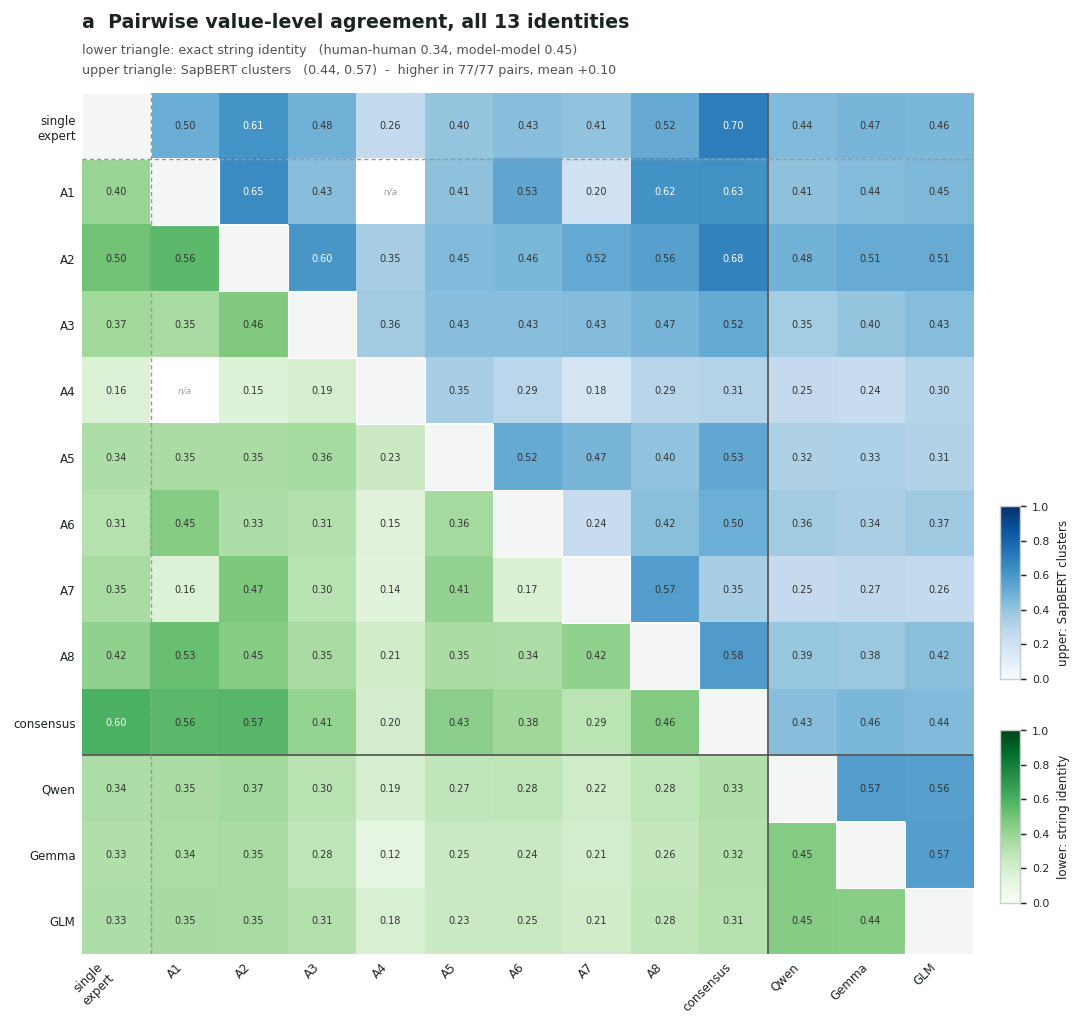

In [20]:
draw("panel_a", (8.4, 8.0), with_colorbars=True)

## Step 13. Where does forgiving wording help? &rarr; panel e

Pooled per metadata category, not per label. Forty-two label-level shifts is a
list, not a result. The question is whether forgiving wording helps biological,
technical and experimental-design fields differently.

In [21]:
labels_in_category = defaultdict(list)
for label in labels:
    labels_in_category[LABEL_CATEGORY[label]].append(label)

rows = []
for category in CATEGORY_ORDER:
    category_labels = labels_in_category.get(category, [])
    if not category_labels:
        continue
    for a, b in itertools.combinations(identities, 2):
        pooled = {"string": ([], []), "clustered": ([], [])}
        for scheme, categories in (("string", string_categories),
                                   ("clustered", clustered_categories)):
            for label in category_labels:
                per_identity = categories[label]
                if a not in per_identity or b not in per_identity:
                    continue
                for doc in sorted(set(per_identity[a]) & set(per_identity[b])):
                    pooled[scheme][0].append(per_identity[a][doc])
                    pooled[scheme][1].append(per_identity[b][doc])

        k_string, k_clustered = cohen_kappa(*pooled["string"]), cohen_kappa(*pooled["clustered"])
        if not pooled["string"][0] or np.isnan(k_string) or np.isnan(k_clustered):
            continue
        rows.append({"category": category, "n_labels": len(category_labels),
                     "annotator_a": a, "annotator_b": b, "pair_category": pair_type(a, b),
                     "n_items": len(pooled["string"][0]),
                     "string_kappa": k_string, "sapbert_kappa": k_clustered,
                     "shift": k_clustered - k_string})

movement = pd.DataFrame(rows)
movement.to_csv(RESULTS / "value_movement_by_category.csv", index=False)

human_movement = movement[movement["pair_category"].isin(HUMAN_PAIR_TYPES)]
stats["movement"] = {
    c: {"n_labels": int(s["n_labels"].iloc[0]), "n_pairs": int(len(s)),
        "string_kappa": float(s["string_kappa"].mean()),
        "sapbert_kappa": float(s["sapbert_kappa"].mean()),
        "shift": float(s["shift"].mean())}
    for c, s in human_movement.groupby("category")}
stats["movement_pooled"] = {
    "string_kappa": float(human_movement["string_kappa"].mean()),
    "sapbert_kappa": float(human_movement["sapbert_kappa"].mean())}
stats["movement_direction"] = {
    "n_category_pairs": int(len(movement)), "n_down": int((movement["shift"] < -1e-9).sum()),
    "worst_down": float(movement["shift"].min())}

print("human pairs, pooled per category:")
for category, s in stats["movement"].items():
    print(f"  {category:20s} {s['string_kappa']:.3f} -> {s['sapbert_kappa']:.3f} "
          f"({s['shift']:+.3f}) over {s['n_labels']} labels")

human pairs, pooled per category:
  biological           0.373 -> 0.456 (+0.084) over 12 labels
  experimental_design  0.224 -> 0.274 (+0.049) over 10 labels
  technical            0.316 -> 0.428 (+0.112) over 20 labels


### Panel e

What forgiving wording does, pooled per metadata category.

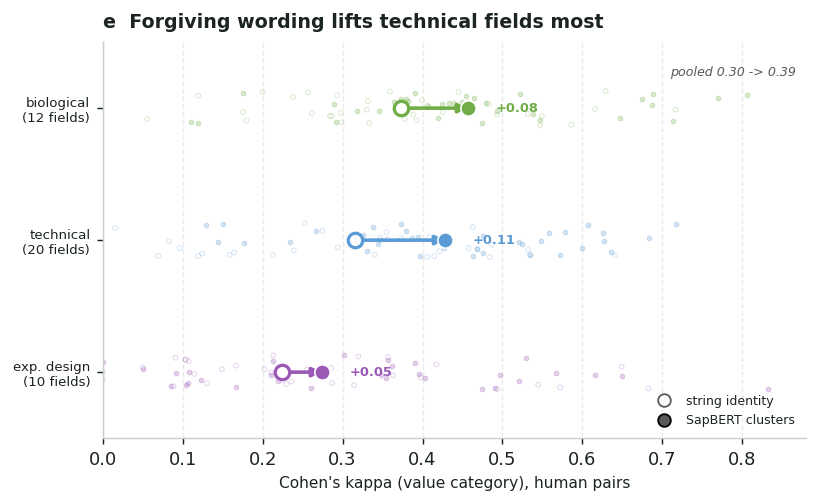

In [22]:
draw("panel_e", (6.4, 4.0))

## Step 14. Does rarity explain difficulty? &rarr; panel c annotation

If the hard fields were simply the uncommon ones, mean per-label kappa would
rise with mention rate.

In [23]:
human_label_pairs = label_pairs[label_pairs["pair_category"].isin(HUMAN_PAIR_TYPES)]
mean_kappa_per_label = human_label_pairs.groupby("label")["kappa"].mean()

rho, pvalue = spearmanr(mean_kappa_per_label.reindex(mention_rates["label"]),
                        mention_rates["mention_rate"])
stats["rarity_vs_difficulty"] = {"rho": float(rho), "p": float(pvalue),
                                 "n_labels": int(len(mention_rates))}
print(f"rho = {rho:+.3f}, p = {pvalue:.3g} over {len(mention_rates)} labels")

rho = +0.071, p = 0.655 over 42 labels


## Step 15. Write everything out

In [24]:
with open(RESULTS / "figure1_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

for path in sorted(RESULTS.glob("*")):
    print(f"  {path.name}")
print(f"\nDone. {len(identities)} identities, {len(labels)} labels, {n_documents} papers, "
      f"model {stats['embedding_model_name']}.")

  agreement_decomposition.csv
  figure1_stats.json
  label_agreement_presence.csv
  label_mention_rate.csv
  pair_agreement_value_sapbert.csv
  pair_agreement_value_string.csv
  value_match_by_label.csv
  value_movement_by_category.csv

Done. 13 identities, 42 labels, 27 papers, model cambridgeltl/SapBERT-from-PubMedBERT-fulltext.


## The composite figure

All five panels as the manuscript shows them. This also writes
`figures/manuscript_figure1/figure1.png` and the standalone panels.

/home/tine/git/Publication/textmining/plot_style.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/figure1.png


Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/panels/figure1_panel_a_pairwise_agreement.png


Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/panels/figure1_panel_b_agreement_decomposition.png


Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/panels/figure1_panel_c_difficulty_vs_rarity.png


Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/panels/figure1_panel_d_value_level_agreement.png
Saved: /home/tine/git/Publication/textmining/final_analyses/HumanAnnotation/figures/manuscript_figure1/panels/figure1_panel_e_forgiving_wording.png


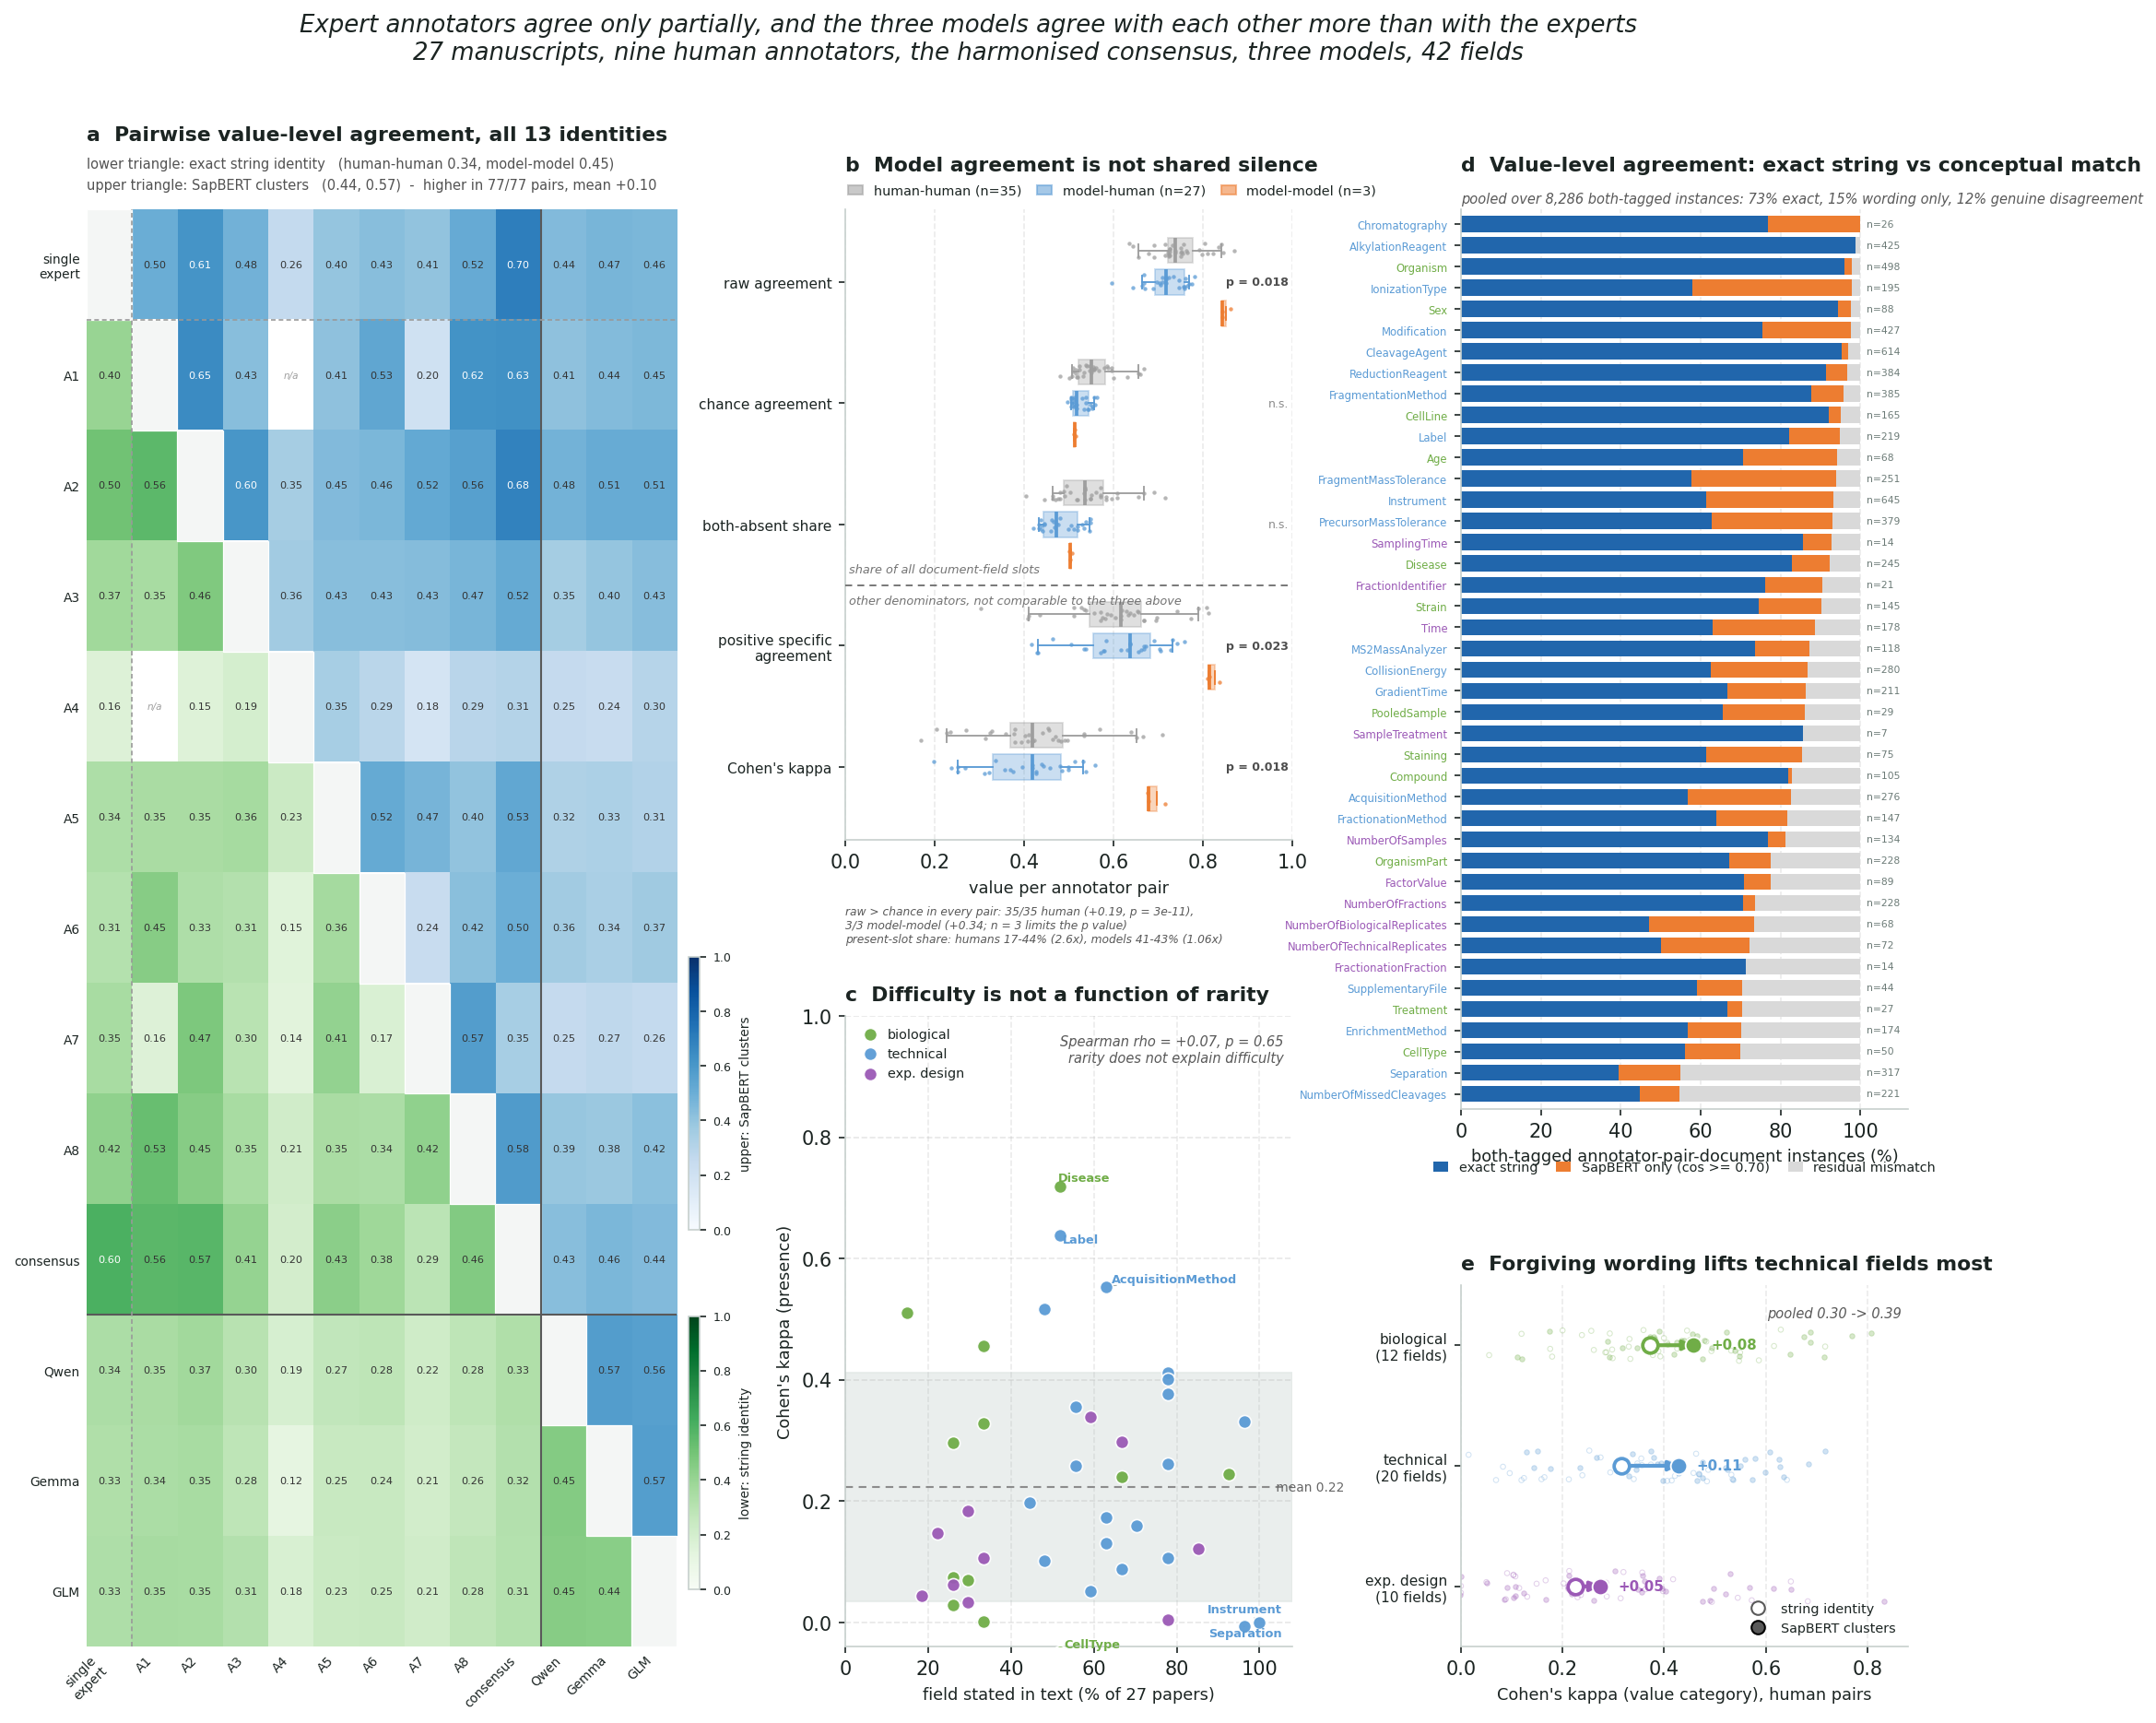

In [25]:
importlib.reload(build_figure1)
build_figure1.main()

display(Image(filename=str(REPO / "final_analyses" / "HumanAnnotation" /
                           "figures" / "manuscript_figure1" / "figure1.png")))

## Step 16. Negative control: is 0.70 a safe threshold for this model?

This is the measurement that decided the model. Tier 5 of the matcher used
SciBERT until 2026-09-04; it now uses SapBERT, and this cell is the evidence.
Run it once with `EMBEDDING_MODEL = "sapbert"` and once with `"scibert"` to
reproduce both rows of the table in the introduction.

Pairs are drawn from genuinely unrelated labels, an Organism value against a
CleavageAgent value and so on, where a true match is impossible by construction.
Anything at or above the threshold is a false match the pipeline would accept.

In [26]:
UNRELATED_LABEL_PAIRS = [
    ("Organism", "CleavageAgent"), ("Organism", "Instrument"),
    ("Disease", "AcquisitionMethod"), ("CellType", "FragmentationMethod"),
    ("Sex", "Instrument"), ("OrganismPart", "AlkylationReagent"),
    ("CellLine", "GradientTime"), ("Age", "Modification"),
]

rows = []
for label_a, label_b in UNRELATED_LABEL_PAIRS:
    values_a = sorted({tidy(v) for docs in annotations.values()
                       for e in docs.values() for v in e.get(label_a, [])})
    values_b = sorted({tidy(v) for docs in annotations.values()
                       for e in docs.values() for v in e.get(label_b, [])})
    if not values_a or not values_b:
        continue
    sims = embed(values_a) @ embed(values_b).T
    for i, va in enumerate(values_a):
        for j, vb in enumerate(values_b):
            rows.append({"label_a": label_a, "label_b": label_b,
                         "value_a": va, "value_b": vb, "similarity": float(sims[i, j])})

control = pd.DataFrame(rows)
false_matches = control[control["similarity"] >= SEMANTIC_THRESHOLD]

print(f"{EMBEDDING_MODEL} on {len(control):,} pairs from unrelated labels")
print(f"  max cosine        {control['similarity'].max():.3f}")
print(f"  99th percentile   {control['similarity'].quantile(0.99):.3f}")
print(f"  median            {control['similarity'].median():.3f}")
print(f"  at or above {SEMANTIC_THRESHOLD}: {len(false_matches):,} "
      f"({100 * len(false_matches) / len(control):.2f}%)")

stats["negative_control"] = {
    "n_pairs": int(len(control)),
    "max": float(control["similarity"].max()),
    "p99": float(control["similarity"].quantile(0.99)),
    "median": float(control["similarity"].median()),
    "n_above_threshold": int(len(false_matches)),
    "pct_above_threshold": float(100 * len(false_matches) / len(control)),
}
with open(RESULTS / "figure1_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

false_matches.nlargest(15, "similarity")

sapbert on 88,226 pairs from unrelated labels
  max cosine        0.665
  99th percentile   0.451
  median            0.305
  at or above 0.7: 0 (0.00%)


,label_a,label_b,value_a,value_b,similarity


Anything at or above the threshold here is a pair the matcher would accept as a
semantic match although no true match exists. For SciBERT that was 18.2% of
pairs, which inflated every score the tier feeds: the vocabulary recovery in
panel d, the SDRF benchmark F1, and the record-versus-article concordance.

A low figure here is what licenses the semantic tier. It does not make the tier
correct, it makes it not obviously wrong, which is the weaker claim the data
supports.